# Import Packages

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data

In [5]:
#df_score = pd.read_csv(r'Comfort_Long.csv')
df_snr = pd.read_csv(r'SNR_Long.csv')

# Comfort Score Figure

In [3]:
save_plot = True

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_score, x='Contrast', y='Comfort_Score', hue='Size', palette='colorblind', linewidth=1.5, legend=False)
plt.xlabel('Contrast Level', fontsize=12)
plt.ylabel('Comfort Score', fontsize=12)
plt.ylim(0.9, 6.0)
plt.tight_layout()

if save_plot:
    plt.savefig(r"Comfort_Figure.svg")

plt.show()

NameError: name 'df_score' is not defined

<Figure size 1200x700 with 0 Axes>

# SNR Figure

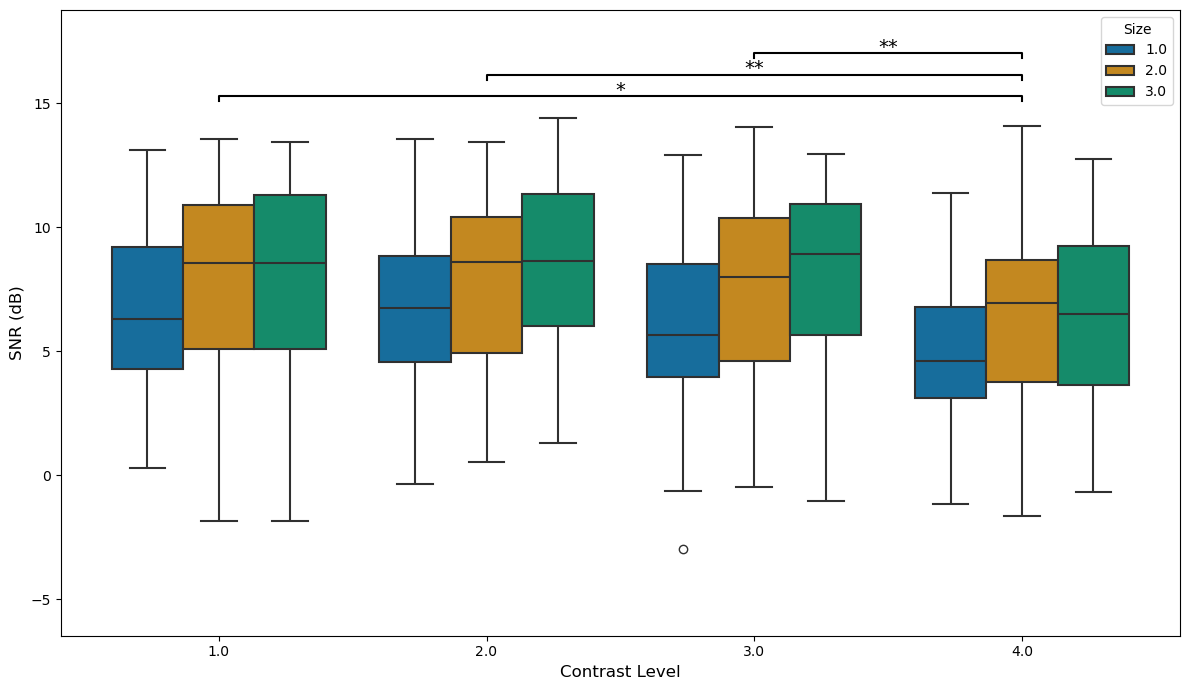

In [6]:
save_plot = False

plt.figure(figsize=(12, 7))
plt.ylim(-3.4, 17.0)

# Create boxplot
ax = sns.boxplot(data=df_snr, x='Contrast', y='SNR', hue='Size', 
                  palette='colorblind', linewidth=1.5, legend=True)

plt.xlabel('Contrast Level', fontsize=12)
plt.ylabel('SNR (dB)', fontsize=12)

# ============================================
# SIGNIFICANCE ANNOTATIONS FOR CONTRAST EFFECT
# ============================================

# Define contrast levels (assuming C1=highest, C4=lowest)
# Adjust x-positions based on your actual contrast level positions
# With 4 contrast levels, x-positions are typically 0, 1, 2, 3

contrast_positions = [0, 1, 2, 3]  # C1, C2, C3, C4

# Significance brackets: C4 vs C1, C4 vs C2, C4 vs C3
# Format: (x1, x2, y_height, p_value_text)

# Get the maximum y-value from your data to position brackets
y_max = df_snr['SNR'].max()
y_min = df_snr['SNR'].min()
y_range = y_max - y_min

# Position brackets at different heights to avoid overlap
bracket_height_c4_c1 = y_max + (y_range * 0.05)      # Lowest bracket
bracket_height_c4_c2 = y_max + (y_range * 0.10)      # Middle bracket  
bracket_height_c4_c3 = y_max + (y_range * 0.15)      # Highest bracket

# Function to draw a significance bracket
def add_significance_bracket(ax, x1, x2, y, p_text, fontsize=10, linewidth=1.5):
    """Draw a significance bracket between two x-positions at height y"""
    # Horizontal line
    ax.plot([x1, x1, x2, x2], [y - 0.2, y, y, y - 0.2], 
            color='black', linewidth=linewidth)
    # p-value text
    ax.text((x1 + x2) / 2, y - 0.15, p_text, 
            ha='center', va='bottom', fontsize=14)

# Add brackets for C4 (position 3) vs C1 (position 0), C2 (position 1), C3 (position 2)
add_significance_bracket(ax, x1=contrast_positions[3], x2=contrast_positions[0], 
                         y=bracket_height_c4_c1, p_text='*')
add_significance_bracket(ax, x1=contrast_positions[3], x2=contrast_positions[1], 
                         y=bracket_height_c4_c2, p_text='**')
add_significance_bracket(ax, x1=contrast_positions[3], x2=contrast_positions[2], 
                         y=bracket_height_c4_c3, p_text='**')

# Adjust y-limit to accommodate brackets
plt.ylim(y_min - (y_range * 0.2), y_max + (y_range * 0.25))

plt.tight_layout()

if save_plot:
    plt.savefig(r"SNR_Figure.svg", format='svg', dpi=300)

plt.show()

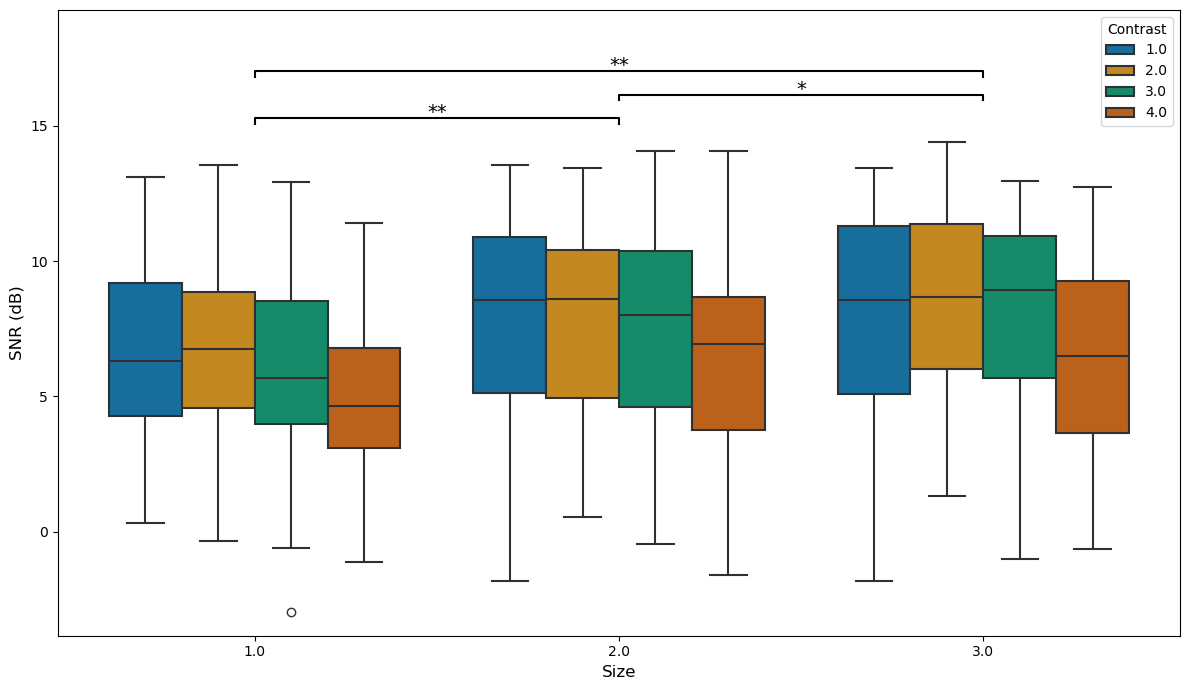

In [7]:
plt.figure(figsize=(12, 7))
plt.ylim(-3.4, 17.0)

ax = sns.boxplot(data=df_snr, x='Size', y='SNR', hue='Contrast', 
                  palette='colorblind', linewidth=1.5, legend=True)

plt.xlabel('Size', fontsize=12)
plt.ylabel('SNR (dB)', fontsize=12)

# ============================================
# SIGNIFICANCE ANNOTATIONS FOR SIZE EFFECT
# ============================================

# Define size positions (assuming S1=smallest, S2=medium, S3=largest)
# With 3 size levels, x-positions are typically 0, 1, 2
size_positions = [0, 1, 2]  # S1, S2, S3

# Get the maximum y-value from your data to position brackets
y_max = df_snr['SNR'].max()
y_min = df_snr['SNR'].min()
y_range = y_max - y_min

# Position brackets at different heights
bracket_height_s1_s2 = y_max + (y_range * 0.05)   # Lowest bracket
bracket_height_s2_s3 = y_max + (y_range * 0.10)   # Middle bracket
bracket_height_s1_s3 = y_max + (y_range * 0.15)   # Highest bracket

# Function to draw a significance bracket
def add_significance_bracket(ax, x1, x2, y, p_text, fontsize=10, linewidth=1.5):
    """Draw a significance bracket between two x-positions at height y"""
    # Horizontal line with vertical drops
    ax.plot([x1, x1, x2, x2], [y - 0.2, y, y, y - 0.2], 
            color='black', linewidth=linewidth)
    # p-value text
    ax.text((x1 + x2) / 2, y - 0.15, p_text, 
            ha='center', va='bottom', fontsize=14)

# Add brackets for all size comparisons
# S1 vs S2 (p < .001)
add_significance_bracket(ax, x1=size_positions[0], x2=size_positions[1], 
                         y=bracket_height_s1_s2, p_text='**')

# S2 vs S3 (p = .049)
add_significance_bracket(ax, x1=size_positions[1], x2=size_positions[2], 
                         y=bracket_height_s2_s3, p_text='*')

# S1 vs S3 (p < .001)
add_significance_bracket(ax, x1=size_positions[0], x2=size_positions[2], 
                         y=bracket_height_s1_s3, p_text='**')

# Adjust y-limit to accommodate brackets
plt.ylim(y_min - (y_range * 0.05), y_max + (y_range * 0.28))

plt.tight_layout()

if save_plot:
    plt.savefig(r"SNR_Figure_2.svg", format='svg', dpi=300)

plt.show()

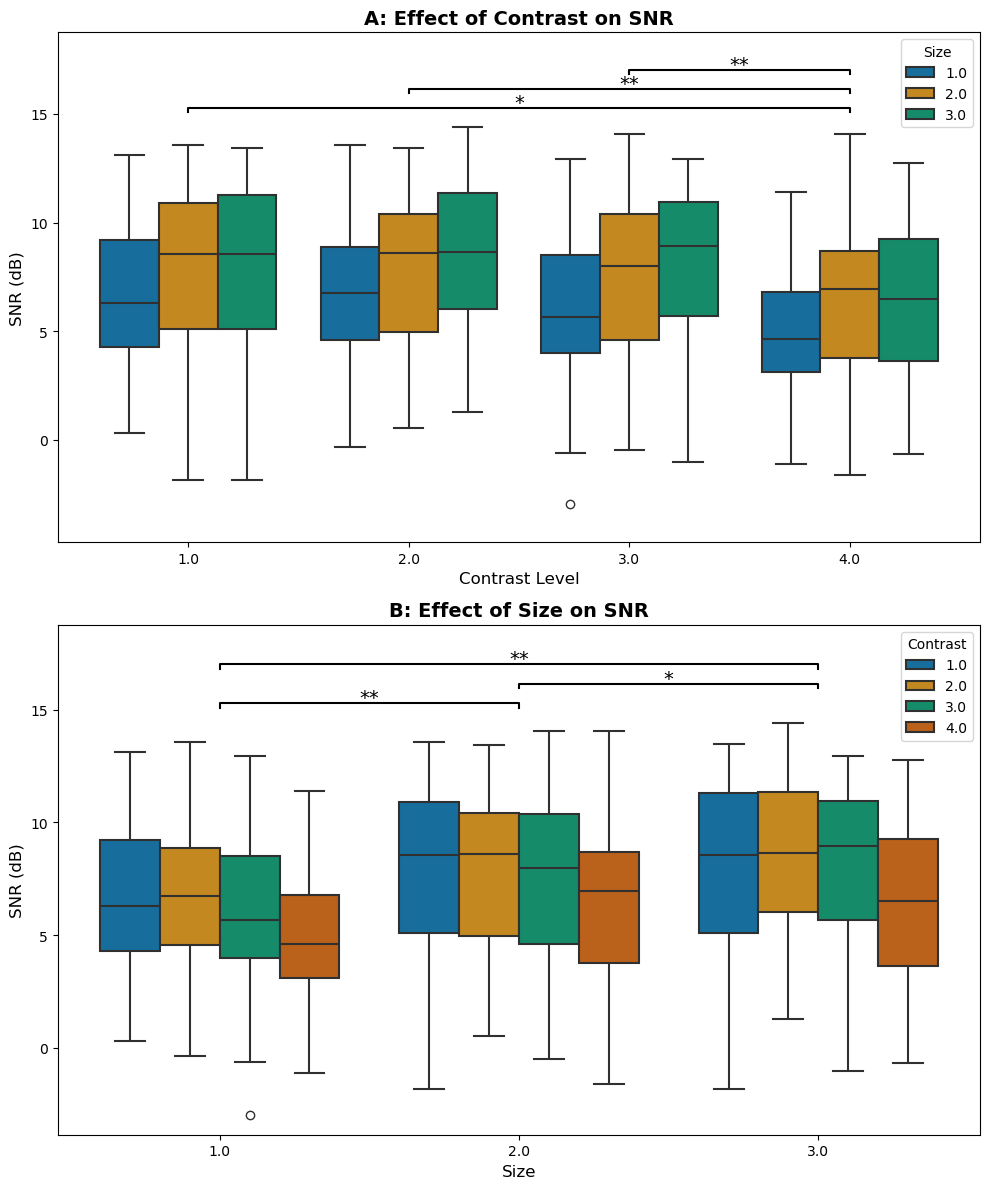

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================
# CREATE FIGURE WITH TWO SUBPLOTS
# ============================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# ============================================
# PLOT 1: CONTRAST EFFECT (Top)
# ============================================

sns.boxplot(data=df_snr, x='Contrast', y='SNR', hue='Size', 
            palette='colorblind', linewidth=1.5, legend=True, ax=ax1)

ax1.set_xlabel('Contrast Level', fontsize=12)
ax1.set_ylabel('SNR (dB)', fontsize=12)
ax1.set_title('A: Effect of Contrast on SNR', fontsize=14, fontweight='bold')

# Get y-limits for significance brackets
y_max1 = df_snr['SNR'].max()
y_min1 = df_snr['SNR'].min()
y_range1 = y_max1 - y_min1

# Contrast positions (C1, C2, C3, C4)
contrast_positions = [0, 1, 2, 3]

# Bracket heights for contrast
bracket_height_c4_c1 = y_max1 + (y_range1 * 0.05)
bracket_height_c4_c2 = y_max1 + (y_range1 * 0.10)
bracket_height_c4_c3 = y_max1 + (y_range1 * 0.15)

# Function to draw significance bracket
def add_bracket(ax, x1, x2, y, p_text, fontsize=14, linewidth=1.5):
    ax.plot([x1, x1, x2, x2], [y - 0.2, y, y, y - 0.2], 
            color='black', linewidth=linewidth)
    ax.text((x1 + x2) / 2, y - 0.18, p_text, 
            ha='center', va='bottom', fontsize=fontsize)

# Add contrast significance brackets
add_bracket(ax1, x1=contrast_positions[3], x2=contrast_positions[0], 
            y=bracket_height_c4_c1, p_text='*')
add_bracket(ax1, x1=contrast_positions[3], x2=contrast_positions[1], 
            y=bracket_height_c4_c2, p_text='**')
add_bracket(ax1, x1=contrast_positions[3], x2=contrast_positions[2], 
            y=bracket_height_c4_c3, p_text='**')

# Set y-limit for top plot
ax1.set_ylim(y_min1 - (y_range1 * 0.1), y_max1 + (y_range1 * 0.25))

# ============================================
# PLOT 2: SIZE EFFECT (Bottom)
# ============================================

sns.boxplot(data=df_snr, x='Size', y='SNR', hue='Contrast', 
            palette='colorblind', linewidth=1.5, legend=True, ax=ax2)

ax2.set_xlabel('Size', fontsize=12)
ax2.set_ylabel('SNR (dB)', fontsize=12)
ax2.set_title('B: Effect of Size on SNR', fontsize=14, fontweight='bold')

# Get y-limits for significance brackets
y_max2 = df_snr['SNR'].max()
y_min2 = df_snr['SNR'].min()
y_range2 = y_max2 - y_min2

# Size positions (S1, S2, S3)
size_positions = [0, 1, 2]

# Bracket heights for size
bracket_height_s1_s2 = y_max2 + (y_range2 * 0.05)
bracket_height_s2_s3 = y_max2 + (y_range2 * 0.10)
bracket_height_s1_s3 = y_max2 + (y_range2 * 0.15)

# Add size significance brackets
add_bracket(ax2, x1=size_positions[0], x2=size_positions[1], 
            y=bracket_height_s1_s2, p_text='**')
add_bracket(ax2, x1=size_positions[1], x2=size_positions[2], 
            y=bracket_height_s2_s3, p_text='*')
add_bracket(ax2, x1=size_positions[0], x2=size_positions[2], 
            y=bracket_height_s1_s3, p_text='**')

# Set y-limit for bottom plot
ax2.set_ylim(y_min2 - (y_range2 * 0.05), y_max2 + (y_range2 * 0.25))

# ============================================
# FINAL TOUCHES
# ============================================

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure
save_plot = True
if save_plot:
    plt.savefig(r"SNR_Combined_Figure.svg", format='svg', dpi=300)

plt.show()

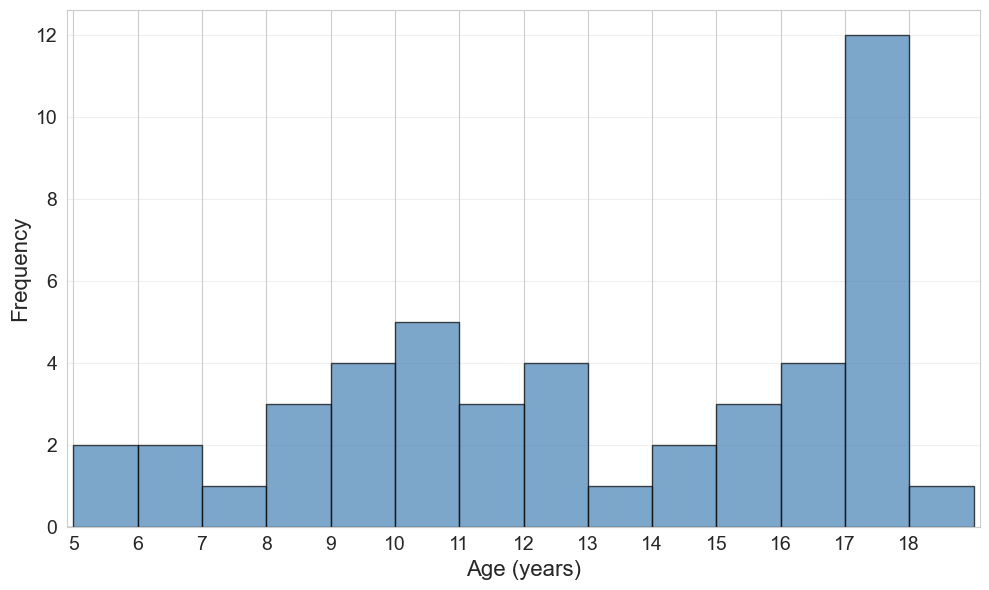

In [26]:
ages = [12,10,12,13,16,14,9,17,16,8,11,9,10,17,17,6,16,17,15,10,12,8,11,17,17,17,9,17,17,17,17,18,10,12,11,9,17,14,5,15,15,16,5,8,6,7,10]


plt.figure(figsize=(10, 6))
plt.hist(ages, bins=range(4, 20), edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Age (years)', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.xticks(range(5, 19, 1), fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(4.9, 19.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(r"Histogram.svg", format='svg', dpi=300)

plt.show()